Treinando o Classificador
No notebook anterior, a gente montou o LunaModel -- uma CNN 3D com 222K parametros que recebe crops de 32x48x48 e devolve duas probabilidades: nodulo ou nao-nodulo. Mas o modelo nao sabe nada ainda, as predicoes sao puro chute.

Agora e hora de ensinar. A gente vai:

Definir a funcao de perda (CrossEntropyLoss) e o otimizador (SGD)
Entender por que treinar "do jeito normal" nao funciona (desbalanceamento)
Criar batches balanceados com o mecanismo de intercalacao (ratio_int)
Aplicar data augmentation 3D pra gerar variacao nos positivos
Montar o loop de treino completo com metricas
Na segunda parte do notebook, tem as instrucoes pra rodar o treinamento completo no Google Colab durante a semana. Na proxima aula, a gente usa um checkpoint pre-treinado pra avaliacao.

In [1]:
import copy
import math
import random
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

sys.path.insert(0, str(Path("../src")))
from luna_data import load_candidates, get_ct, LunaDataset
from model import LunaModel

In [2]:
candidates = load_candidates()
n_pos = sum(1 for c in candidates if c.is_nodule)
n_neg = len(candidates) - n_pos

print(f"Candidatos: {len(candidates)}")
print(f"Nodulos: {n_pos}")
print(f"Nao-nodulos: {n_neg}")

Candidatos: 551065
Nodulos: 1351
Nao-nodulos: 549714


A funcao de perda: CrossEntropyLoss
Pra treinar qualquer rede neural, a gente precisa de uma funcao que diga "quao errado voce esta". Isso e a funcao de perda (loss function). No nosso caso, estamos fazendo classificacao binaria com duas saidas, entao usamos CrossEntropyLoss.

O CrossEntropyLoss recebe dois inputs:

Os logits do modelo (valores crus, antes do softmax) com shape [batch, 2]
O indice da classe correta pra cada sample -- um escalar 0 ou 1
Um detalhe sobre os labels
No notebook anterior, a gente definiu o label como um vetor [not_nodule, nodule]. Por exemplo, um nodulo tem label [0, 1] e um nao-nodulo tem [1, 0].

A gente disse que esse era "o formato que o CrossEntropyLoss espera", mas na verdade o CrossEntropyLoss espera o indice da classe correta (um escalar 0 ou 1), nao o vetor inteiro. A gente guardou no formato de vetor porque e conveniente pra visualizacao, mas na hora do treino precisa extrair o indice.

Pra fazer isso, basta pegar a segunda posicao do vetor: labels[:, 1]. Assim, [0, 1] vira 1 (nodulo) e [1, 0] vira 0 (nao-nodulo).

In [3]:
ds = LunaDataset()
crop_t, label_t, uid, center = ds[0]

print(f"Label do nodulo (vetor): {label_t}")
print(f"Indice da classe (escalar): {label_t[1].item()}")

Label do nodulo (vetor): tensor([0, 1])
Indice da classe (escalar): 1


Vamos ver na pratica: criar o modelo, pegar um batch e computar a loss.

In [4]:
model = LunaModel()
loader = DataLoader(ds, batch_size=4)
crops, labels, uids, centers = next(iter(loader))

logits, probs = model(crops)

loss_fn = nn.CrossEntropyLoss()
loss = loss_fn(logits, labels[:, 1])

print(f"Logits shape: {logits.shape}")
print(f"Labels (indices): {labels[:, 1]}")
print(f"Loss: {loss.item():.4f}")

Logits shape: torch.Size([4, 2])
Labels (indices): tensor([1, 1, 1, 1])
Loss: 0.1395


O otimizador: SGD com momentum
O otimizador e quem atualiza os pesos do modelo na direcao que reduz a loss. Vamos usar SGD com momentum -- Stochastic Gradient Descent com uma "inercia" que suaviza as atualizacoes e ajuda a escapar de minimos locais.

Os hiperparametros:

lr=0.001 -- taxa de aprendizado (passos pequenos)
momentum=0.99 -- bastante inercia, o que funciona bem pra esse problema

In [5]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.99)

O problema do desbalanceamento
Antes de sair treinando, a gente precisa lidar com um problema serio nos nossos dados.

In [6]:
ratio = n_pos / len(candidates) * 100
print(f"Nodulos: {n_pos} ({ratio:.3f}%)")
print(f"Nao-nodulos: {n_neg} ({100-ratio:.3f}%)")
print(f"Proporcao: 1 nodulo pra cada {n_neg // n_pos} nao-nodulos")

Nodulos: 1351 (0.245%)
Nao-nodulos: 549714 (99.755%)
Proporcao: 1 nodulo pra cada 406 nao-nodulos


Pense assim: se o modelo simplesmente chutar "nao-nodulo" pra todos os candidatos, ele acerta 99.75% das vezes. Uma acuracia fantastica... e completamente inutil, porque nao encontra nenhum nodulo.

Lembra no notebook anterior? O modelo nao treinado dava probabilidade 0.00 pra tudo. Se a gente treinar sem balancear, ele vai rapidamente aprender que "chutar nao-nodulo sempre" minimiza a loss. O gradiente dos poucos positivos se perde no meio de centenas de milhares de negativos.

Precisamos de uma estrategia pra garantir que o modelo veja nodulos e nao-nodulos em proporcoes razoaveis durante o treino.

Batches balanceados com ratio_int
A solucao e intercalar positivos e negativos numa proporcao controlada. O parametro ratio_int define quantos negativos aparecem entre cada positivo:

ratio_int=1: um positivo, um negativo, um positivo, um negativo... (proporcao 1:1)
ratio_int=2: um positivo, dois negativos, um positivo, dois negativos... (proporcao 1:2)
Pensa num baralho: em vez de embaralhar tudo (e ter 99.7% de cartas vermelhas), a gente monta o baralho alternando deliberadamente vermelho e preto.

A logica usa aritmetica modular. Pra cada indice idx:

O item e positivo quando idx % (ratio_int + 1) == 0
Nos outros casos, e negativo
Com ratio_int=1, a sequencia fica:

In [7]:
ratio_int = 1
for idx in range(8):
    is_pos = (idx % (ratio_int + 1) == 0)
    tipo = "POS" if is_pos else "NEG"
    print(f"  idx={idx} -> {tipo}")

  idx=0 -> POS
  idx=1 -> NEG
  idx=2 -> POS
  idx=3 -> NEG
  idx=4 -> POS
  idx=5 -> NEG
  idx=6 -> POS
  idx=7 -> NEG


Com ratio_int=2, cada positivo e seguido por dois negativos:

In [8]:
ratio_int = 2
for idx in range(9):
    is_pos = (idx % (ratio_int + 1) == 0)
    tipo = "POS" if is_pos else "NEG"
    print(f"  idx={idx} -> {tipo}")

  idx=0 -> POS
  idx=1 -> NEG
  idx=2 -> NEG
  idx=3 -> POS
  idx=4 -> NEG
  idx=5 -> NEG
  idx=6 -> POS
  idx=7 -> NEG
  idx=8 -> NEG


Epoca de tamanho fixo
Com o ratio_int ativo, a "epoca" nao percorre todos os 551K candidatos (isso demoraria demais). Em vez disso, fixamos o tamanho da epoca em 200.000 amostras. Os positivos sao repetidos ciclicamente conforme necessario, e os negativos sao amostrados com wrapping.

A cada epoca, embaralhamos as listas de positivos e negativos separadamente. Assim o modelo ve os mesmos dados em ordens diferentes a cada passada.

Com ratio_int=1 e 200K amostras por epoca, cada positivo aparece ~74 vezes (100K positivos / 1351 unicos). E muita repeticao -- mas e ai que entra a data augmentation.

Data Augmentation 3D
Se cada positivo aparece ~74 vezes por epoca, e o modelo vir sempre o mesmo crop identico, ele vai decorar esses 1351 exemplos em vez de aprender padroes gerais. A solucao e data augmentation: cada vez que um crop e acessado, aplicamos transformacoes aleatorias que criam uma versao ligeiramente diferente.

E como tirar varias fotos do mesmo objeto de angulos diferentes -- o objeto e o mesmo, mas cada foto e unica.

As transformacoes que vamos usar:

Flip: espelhar aleatoriamente em cada eixo (50% de chance por eixo)
Offset: deslocar levemente o crop (+/- 10% em cada eixo)
Scale: aumentar ou diminuir levemente (+/- 20%)
Rotacao: girar em angulo aleatorio no plano axial (0 a 360 graus)
Ruido: adicionar ruido gaussiano (std=25 HU)
Tudo isso e feito via transformacao afim (F.affine_grid + F.grid_sample), que aplica todas as transformacoes geometricas de uma vez so, sem perder qualidade.

A matriz de transformacao
A ideia e montar uma matriz 4x4 que descreve todas as transformacoes geometricas (flip, offset, scale, rotacao) de uma vez. Depois, o PyTorch gera uma grade de coordenadas transformadas (affine_grid) e reamostra o volume original nessas novas coordenadas (grid_sample).

Pense assim: em vez de realmente mover os voxels (o que distorceria), a gente cria um "mapa" que diz "o voxel na posicao (i, j, k) do resultado deve pegar o valor da posicao (i', j', k') do original". As posicoes (i', j', k') sao calculadas pela matriz.

In [9]:
def augment_candidate(crop_t, augmentation_dict):
    transform_t = torch.eye(4)

    for i in range(3):
        if 'flip' in augmentation_dict:
            if random.random() > 0.5:
                transform_t[i, i] *= -1
        if 'offset' in augmentation_dict:
            offset_float = augmentation_dict['offset']
            random_float = (random.random() * 2 - 1)
            transform_t[i, 3] = offset_float * random_float
        if 'scale' in augmentation_dict:
            scale_float = augmentation_dict['scale']
            random_float = (random.random() * 2 - 1)
            transform_t[i, i] *= 1.0 + scale_float * random_float

    if 'rotate' in augmentation_dict:
        angle_rad = random.random() * math.pi * 2
        s = math.sin(angle_rad)
        c = math.cos(angle_rad)
        rotation_t = torch.tensor([
            [c, -s, 0, 0],
            [s, c, 0, 0],
            [0, 0, 1, 0],
            [0, 0, 0, 1],
        ])
        transform_t @= rotation_t

    affine_t = F.affine_grid(
        transform_t[:3].unsqueeze(0).to(torch.float32),
        crop_t.unsqueeze(0).size(),
        align_corners=False,
    )
    augmented_t = F.grid_sample(
        crop_t.unsqueeze(0),
        affine_t,
        padding_mode='border',
        align_corners=False,
    ).squeeze(0)

    if 'noise' in augmentation_dict:
        noise_t = torch.randn_like(augmented_t)
        noise_t *= augmentation_dict['noise']
        augmented_t += noise_t

    return augmented_t

Visualizando a augmentation
Essa e a parte mais importante pra entender o que esta acontecendo. Vamos pegar um crop de nodulo e aplicar a augmentation varias vezes pra ver como cada versao fica diferente.

In [10]:
nodule_crop, _, _, _ = ds[0]

aug_dict = {
    'flip': True,
    'offset': 0.1,
    'scale': 0.2,
    'rotate': True,
    'noise': 25.0,
}

augmented = [augment_candidate(nodule_crop, aug_dict) for _ in range(5)]


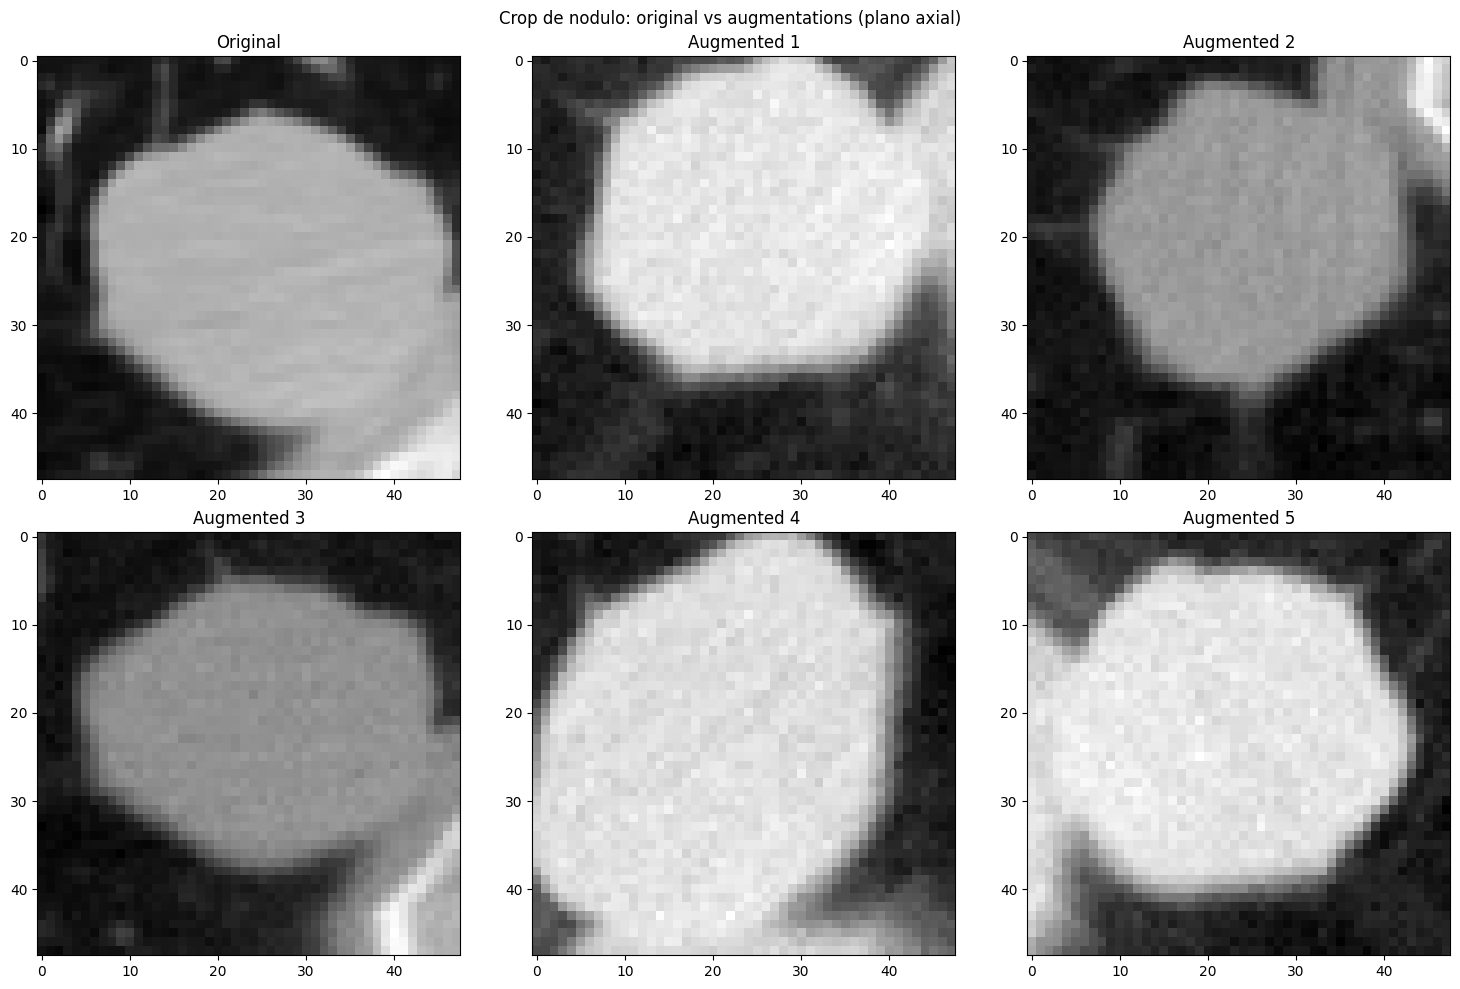

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].imshow(nodule_crop[0, 16], cmap="gray")
axes[0, 0].set_title("Original")

for i, aug in enumerate(augmented):
    row, col = (i + 1) // 3, (i + 1) % 3
    axes[row, col].imshow(aug[0, 16], cmap="gray")
    axes[row, col].set_title(f"Augmented {i+1}")

plt.suptitle("Crop de nodulo: original vs augmentations (plano axial)")
plt.tight_layout()
plt.show()

Repare como cada versao augmentada e ligeiramente diferente: o nodulo pode estar espelhado, deslocado, rotacionado, com um pouco mais de ruido. Mas continua sendo reconhecivelmente o mesmo nodulo. Isso e exatamente o que a gente quer.

Agora vamos comparar o original e uma versao augmentada nos tres planos anatomicos:

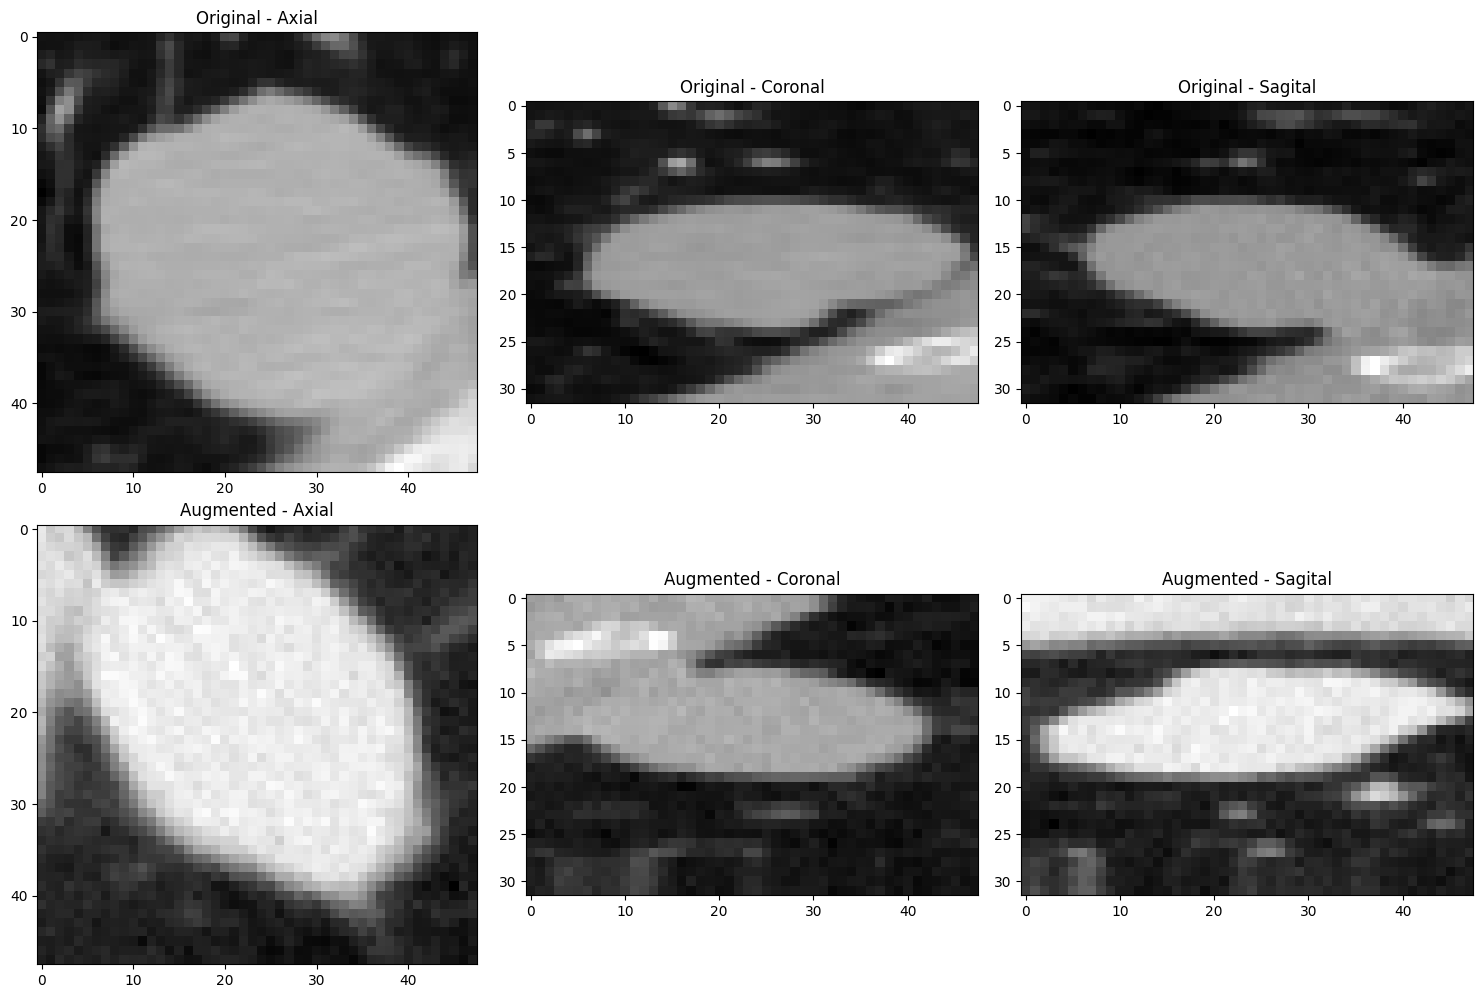

In [12]:
aug_crop = augment_candidate(nodule_crop, aug_dict)
d, h, w = nodule_crop.shape[1], nodule_crop.shape[2], nodule_crop.shape[3]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].imshow(nodule_crop[0, d // 2], cmap="gray")
axes[0, 0].set_title("Original - Axial")
axes[0, 1].imshow(nodule_crop[0, :, h // 2, :], cmap="gray")
axes[0, 1].set_title("Original - Coronal")
axes[0, 2].imshow(nodule_crop[0, :, :, w // 2], cmap="gray")
axes[0, 2].set_title("Original - Sagital")

axes[1, 0].imshow(aug_crop[0, d // 2], cmap="gray")
axes[1, 0].set_title("Augmented - Axial")
axes[1, 1].imshow(aug_crop[0, :, h // 2, :], cmap="gray")
axes[1, 1].set_title("Augmented - Coronal")
axes[1, 2].imshow(aug_crop[0, :, :, w // 2], cmap="gray")
axes[1, 2].set_title("Augmented - Sagital")

plt.tight_layout()
plt.show()

Dataset de treino balanceado
Agora vamos juntar tudo: intercalacao com ratio_int + augmentation. O LunaTrainingDataset tem dois superpoderes em relacao ao LunaDataset original:

Balanceamento: separa positivos e negativos em listas e intercala via modular arithmetic
Augmentation: aplica transformacoes aleatorias a cada acesso (somente no treino)
A classe fica em training.py, separada do luna_data.py que a gente construiu no notebook anterior.

In [13]:
class LunaTrainingDataset(Dataset):
    def __init__(self, val_stride=0, is_val=False,
                 ratio_int=0, augmentation_dict=None):
        candidates = copy.copy(load_candidates())
        if is_val:
            assert val_stride > 0
            candidates = candidates[::val_stride]
        elif val_stride > 0:
            del candidates[::val_stride]

        self.pos_list = [c for c in candidates if c.is_nodule]
        self.neg_list = [c for c in candidates if not c.is_nodule]
        self.ratio_int = ratio_int
        self.augmentation_dict = augmentation_dict or {}
        self.shuffle_samples()

In [14]:
def shuffle_samples(self):
    random.shuffle(self.pos_list)
    random.shuffle(self.neg_list)

def __len__(self):
    if self.ratio_int:
        return 200_000
    return len(self.pos_list) + len(self.neg_list)

LunaTrainingDataset.shuffle_samples = shuffle_samples
LunaTrainingDataset.__len__ = __len__

In [15]:
def __getitem__(self, idx):
    if self.ratio_int:
        pos_idx = idx // (self.ratio_int + 1)
        if idx % (self.ratio_int + 1) == 0:
            pos_idx %= len(self.pos_list)
            candidate = self.pos_list[pos_idx]
        else:
            neg_idx = idx - 1 - pos_idx
            neg_idx %= len(self.neg_list)
            candidate = self.neg_list[neg_idx]
    else:
        all_list = self.pos_list + self.neg_list
        candidate = all_list[idx]

    ct = get_ct(candidate.series_uid)
    crop_a, center_irc = ct.extract_crop(candidate.center_xyz)
    crop_t = torch.from_numpy(crop_a).to(torch.float32)
    crop_t = crop_t.unsqueeze(0)

    if self.augmentation_dict:
        crop_t = augment_candidate(crop_t, self.augmentation_dict)

    label_t = torch.tensor(
        [not candidate.is_nodule, candidate.is_nodule],
        dtype=torch.long,
    )
    return crop_t, label_t, candidate.series_uid, torch.tensor(center_irc)

LunaTrainingDataset.__getitem__ = __getitem__

Vamos criar o dataset balanceado e verificar que ele intercala positivos e negativos corretamente:

In [16]:
train_ds = LunaTrainingDataset(
    val_stride=10, is_val=False, ratio_int=1,
)

print(f"Amostras por epoca: {len(train_ds)}")
print(f"Positivos unicos: {len(train_ds.pos_list)}")
print(f"Negativos unicos: {len(train_ds.neg_list)}")

Amostras por epoca: 200000
Positivos unicos: 1215
Negativos unicos: 494743


In [17]:
for i in range(6):
    _, label, _, _ = train_ds[i]
    tipo = "POS" if label[1] == 1 else "NEG"
    print(f"  idx={i} -> {tipo}")

  idx=0 -> POS
  idx=1 -> NEG
  idx=2 -> POS
  idx=3 -> NEG
  idx=4 -> POS
  idx=5 -> NEG


Funcoes de treino e validacao
Agora vamos montar as funcoes que executam o treino e a validacao propriamente ditos.

Metricas
Pra acompanhar o treino, a gente precisa de metricas alem da loss. A acuracia geral nao e confiavel (lembra: 99.75% so chutando nao-nodulo). As metricas que importam sao:

Precision: dos que o modelo disse ser nodulo, quantos realmente sao?
Recall: dos nodulos reais, quantos o modelo encontrou?
F1: media harmonica entre precision e recall (equilibra os dois)
A funcao compute_metrics calcula tudo a partir dos contadores TP, FP, FN, TN:

In [18]:
def compute_metrics(tp, fp, fn, tn):
    total = tp + fp + fn + tn
    accuracy = (tp + tn) / total if total > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    acc_pos = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    acc_neg = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return {
        'accuracy': accuracy, 'precision': precision,
        'recall': recall, 'f1': f1,
        'acc_pos': acc_pos, 'acc_neg': acc_neg,
    }

Uma epoca de treino
A funcao train_one_epoch faz o loop padrao do PyTorch: pega cada batch, faz o forward, calcula a loss, faz o backward, atualiza os pesos. Ao longo do caminho, acumula os contadores de TP/FP/FN/TN pra calcular as metricas no final.

O parametro print_every controla o feedback durante a epoca: se for maior que zero, imprime a loss media a cada N batches. Aqui na demo a gente nao precisa (sao poucos batches), mas no Colab com 200K amostras e essencial pra saber que nao travou.

In [19]:
def train_one_epoch(model, loader, optimizer, loss_fn, device, print_every=0):
    model.train()
    total_loss = 0.0
    tp = fp = fn = tn = 0
    n_batches = 0

    for batch in loader:
        crops, labels, _, _ = batch
        crops = crops.to(device)
        labels_idx = labels[:, 1].to(device)

        optimizer.zero_grad()
        logits, probs = model(crops)
        loss = loss_fn(logits, labels_idx)
        loss.backward()
        optimizer.step()

        preds = (probs[:, 1] > 0.5)
        actual = labels_idx.bool()
        tp += (preds & actual).sum().item()
        fp += (preds & ~actual).sum().item()
        fn += (~preds & actual).sum().item()
        tn += (~preds & ~actual).sum().item()

        total_loss += loss.item()
        n_batches += 1

        if print_every > 0 and n_batches % print_every == 0:
            avg = total_loss / n_batches
            print(f"  Batch {n_batches}/{len(loader)} | Loss: {avg:.4f}")

    avg_loss = total_loss / max(n_batches, 1)
    metrics = compute_metrics(tp, fp, fn, tn)
    metrics['loss'] = avg_loss
    return metrics

Validacao
A funcao validate e quase identica, mas com duas diferencas:

model.eval() desativa dropout e muda o comportamento do BatchNorm
torch.no_grad() desliga o calculo de gradientes (economia de memoria)

In [20]:
def validate(model, loader, loss_fn, device, print_every=0):
    model.eval()
    total_loss = 0.0
    tp = fp = fn = tn = 0
    n_batches = 0

    with torch.no_grad():
        for batch in loader:
            crops, labels, _, _ = batch
            crops = crops.to(device)
            labels_idx = labels[:, 1].to(device)

            logits, probs = model(crops)
            loss = loss_fn(logits, labels_idx)

            preds = (probs[:, 1] > 0.5)
            actual = labels_idx.bool()
            tp += (preds & actual).sum().item()
            fp += (preds & ~actual).sum().item()
            fn += (~preds & actual).sum().item()
            tn += (~preds & ~actual).sum().item()

            total_loss += loss.item()
            n_batches += 1

            if print_every > 0 and n_batches % print_every == 0:
                avg = total_loss / n_batches
                print(f"  Batch {n_batches}/{len(loader)} | Loss: {avg:.4f}")

    avg_loss = total_loss / max(n_batches, 1)
    metrics = compute_metrics(tp, fp, fn, tn)
    metrics['loss'] = avg_loss
    return metrics

Demo rapida
Vamos rodar umas poucas iteracoes pra confirmar que tudo funciona. Nao esperamos convergencia -- so queremos ver que a loss e calculada, o backward roda, e as metricas sao computadas sem erro.

(Isso demora um pouco no CPU porque cada sample carrega um CT scan diferente.)

In [21]:
model = LunaModel()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.99)
loss_fn = nn.CrossEntropyLoss()

demo_ds = LunaTrainingDataset(
    val_stride=10, is_val=False, ratio_int=1,
)
demo_loader = DataLoader(demo_ds, batch_size=4, num_workers=0)

model.train()
for i, batch in enumerate(demo_loader):
    if i >= 3:
        break
    crops, labels, _, _ = batch
    optimizer.zero_grad()
    logits, probs = model(crops)
    loss = loss_fn(logits, labels[:, 1])
    loss.backward()
    optimizer.step()

    n_pos = labels[:, 1].sum().item()
    n_neg = len(labels) - int(n_pos)
    print(f"  Batch {i}: loss={loss.item():.4f}, pos={int(n_pos)}, neg={n_neg}")

  Batch 0: loss=1.2805, pos=2, neg=2
  Batch 1: loss=4.4013, pos=2, neg=2
  Batch 2: loss=2.1995, pos=2, neg=2


Salvando checkpoints
Durante o treinamento completo (no Colab), a gente vai salvar o modelo toda vez que o F1 na validacao melhorar. O checkpoint guarda tudo que e necessario pra retomar o treino ou usar o modelo depois:

In [22]:
# Exemplo de como salvar (nao vamos salvar agora, so mostrar o formato)
checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': 1,
    'f1': 0.0,
}

# torch.save(checkpoint, "checkpoints/luna_model_best.pt")
print(f"Checkpoint contem {len(checkpoint)} itens:")
for key in checkpoint:
    print(f"  {key}")

Checkpoint contem 4 itens:
  model_state_dict
  optimizer_state_dict
  epoch
  f1


Exportando o modulo
Agora a gente junta tudo num arquivo Python pra usar no treinamento completo. A celula abaixo usa %%writefile pra escrever src/training.py:

In [23]:
%%writefile ../src/training.py
"""Funcoes de treinamento e dataset balanceado para o LunaModel."""

import copy
import math
import random

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

from luna_data import load_candidates, get_ct


def augment_candidate(crop_t, augmentation_dict):
    """Aplica augmentation 3D a um crop de CT."""
    transform_t = torch.eye(4)

    for i in range(3):
        if 'flip' in augmentation_dict:
            if random.random() > 0.5:
                transform_t[i, i] *= -1
        if 'offset' in augmentation_dict:
            offset_float = augmentation_dict['offset']
            random_float = (random.random() * 2 - 1)
            transform_t[i, 3] = offset_float * random_float
        if 'scale' in augmentation_dict:
            scale_float = augmentation_dict['scale']
            random_float = (random.random() * 2 - 1)
            transform_t[i, i] *= 1.0 + scale_float * random_float

    if 'rotate' in augmentation_dict:
        angle_rad = random.random() * math.pi * 2
        s = math.sin(angle_rad)
        c = math.cos(angle_rad)
        rotation_t = torch.tensor([
            [c, -s, 0, 0],
            [s, c, 0, 0],
            [0, 0, 1, 0],
            [0, 0, 0, 1],
        ])
        transform_t @= rotation_t

    affine_t = F.affine_grid(
        transform_t[:3].unsqueeze(0).to(torch.float32),
        crop_t.unsqueeze(0).size(),
        align_corners=False,
    )
    augmented_t = F.grid_sample(
        crop_t.unsqueeze(0),
        affine_t,
        padding_mode='border',
        align_corners=False,
    ).squeeze(0)

    if 'noise' in augmentation_dict:
        noise_t = torch.randn_like(augmented_t)
        noise_t *= augmentation_dict['noise']
        augmented_t += noise_t

    return augmented_t


class LunaTrainingDataset(Dataset):
    def __init__(self, val_stride=0, is_val=False,
                 ratio_int=0, augmentation_dict=None):
        candidates = copy.copy(load_candidates())
        if is_val:
            assert val_stride > 0
            candidates = candidates[::val_stride]
        elif val_stride > 0:
            del candidates[::val_stride]

        self.pos_list = [c for c in candidates if c.is_nodule]
        self.neg_list = [c for c in candidates if not c.is_nodule]
        self.ratio_int = ratio_int
        self.augmentation_dict = augmentation_dict or {}
        self.shuffle_samples()

    def shuffle_samples(self):
        random.shuffle(self.pos_list)
        random.shuffle(self.neg_list)

    def __len__(self):
        if self.ratio_int:
            return 200_000
        return len(self.pos_list) + len(self.neg_list)

    def __getitem__(self, idx):
        if self.ratio_int:
            pos_idx = idx // (self.ratio_int + 1)
            if idx % (self.ratio_int + 1) == 0:
                pos_idx %= len(self.pos_list)
                candidate = self.pos_list[pos_idx]
            else:
                neg_idx = idx - 1 - pos_idx
                neg_idx %= len(self.neg_list)
                candidate = self.neg_list[neg_idx]
        else:
            all_list = self.pos_list + self.neg_list
            candidate = all_list[idx]

        ct = get_ct(candidate.series_uid)
        crop_a, center_irc = ct.extract_crop(candidate.center_xyz)
        crop_t = torch.from_numpy(crop_a).to(torch.float32)
        crop_t = crop_t.unsqueeze(0)

        if self.augmentation_dict:
            crop_t = augment_candidate(crop_t, self.augmentation_dict)

        label_t = torch.tensor(
            [not candidate.is_nodule, candidate.is_nodule],
            dtype=torch.long,
        )
        return crop_t, label_t, candidate.series_uid, torch.tensor(center_irc)


def compute_metrics(tp, fp, fn, tn):
    """Calcula accuracy, precision, recall e F1."""
    total = tp + fp + fn + tn
    accuracy = (tp + tn) / total if total > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    acc_pos = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    acc_neg = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return {
        'accuracy': accuracy, 'precision': precision,
        'recall': recall, 'f1': f1,
        'acc_pos': acc_pos, 'acc_neg': acc_neg,
    }


def train_one_epoch(model, loader, optimizer, loss_fn, device, print_every=0):
    """Executa uma epoca de treinamento."""
    model.train()
    total_loss = 0.0
    tp = fp = fn = tn = 0
    n_batches = 0

    for batch in loader:
        crops, labels, _, _ = batch
        crops = crops.to(device)
        labels_idx = labels[:, 1].to(device)

        optimizer.zero_grad()
        logits, probs = model(crops)
        loss = loss_fn(logits, labels_idx)
        loss.backward()
        optimizer.step()

        preds = (probs[:, 1] > 0.5)
        actual = labels_idx.bool()
        tp += (preds & actual).sum().item()
        fp += (preds & ~actual).sum().item()
        fn += (~preds & actual).sum().item()
        tn += (~preds & ~actual).sum().item()

        total_loss += loss.item()
        n_batches += 1

        if print_every > 0 and n_batches % print_every == 0:
            avg = total_loss / n_batches
            print(f"  Batch {n_batches}/{len(loader)} | Loss: {avg:.4f}")

    avg_loss = total_loss / max(n_batches, 1)
    metrics = compute_metrics(tp, fp, fn, tn)
    metrics['loss'] = avg_loss
    return metrics


def validate(model, loader, loss_fn, device, print_every=0):
    """Executa validacao (sem gradientes)."""
    model.eval()
    total_loss = 0.0
    tp = fp = fn = tn = 0
    n_batches = 0

    with torch.no_grad():
        for batch in loader:
            crops, labels, _, _ = batch
            crops = crops.to(device)
            labels_idx = labels[:, 1].to(device)

            logits, probs = model(crops)
            loss = loss_fn(logits, labels_idx)

            preds = (probs[:, 1] > 0.5)
            actual = labels_idx.bool()
            tp += (preds & actual).sum().item()
            fp += (preds & ~actual).sum().item()
            fn += (~preds & actual).sum().item()
            tn += (~preds & ~actual).sum().item()

            total_loss += loss.item()
            n_batches += 1

            if print_every > 0 and n_batches % print_every == 0:
                avg = total_loss / n_batches
                print(f"  Batch {n_batches}/{len(loader)} | Loss: {avg:.4f}")

    avg_loss = total_loss / max(n_batches, 1)
    metrics = compute_metrics(tp, fp, fn, tn)
    metrics['loss'] = avg_loss
    return metrics

Overwriting ../src/training.py


Pra confirmar que o import funciona, reinicie o kernel e rode a celula abaixo:

In [24]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("../src")))

from training import LunaTrainingDataset, train_one_epoch, validate, compute_metrics

print("Import OK")
ds = LunaTrainingDataset(val_stride=10, is_val=False, ratio_int=1)
print(f"Dataset: {len(ds)} amostras por epoca")

Import OK
Dataset: 200000 amostras por epoca


---

# ======================================================
# TREINAMENTO COMPLETO DO MODELO
# ======================================================

> **SECAO ADICIONADA PELO ASSISTENTE DE IA**
> 
> As celulas abaixo executam o loop de treinamento completo.
> 
> Configuracao padrao: **5 epocas**, batch_size=32, lr=0.001, momentum=0.99
> 
> Tempo estimado: ~10-20 min por epoca na RTX 4070
> 
> Para ajustar os hiperparametros, modifique a celula de configuracao abaixo.

In [25]:
# ======================================================
# CONFIGURACAO DO TREINAMENTO
# (Secao adicionada pelo assistente de IA)
# ======================================================

import time
import os

# Hiperparametros
N_EPOCHS = 5
BATCH_SIZE = 32
LEARNING_RATE = 0.001
MOMENTUM = 0.99
VAL_STRIDE = 10
RATIO_INT = 2
NUM_WORKERS = 4
PRINT_EVERY = 500

# Augmentation para os positivos
AUGMENTATION_DICT = {
    'flip': True,
    'offset': 0.1,
    'scale': 0.2,
    'rotate': True,
    'noise': 25.0,
}

# Device (GPU se disponivel)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Diretorio de checkpoints
os.makedirs("../checkpoints", exist_ok=True)

print(f"\nConfiguracao:")
print(f"  Epocas: {N_EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Momentum: {MOMENTUM}")
print(f"  Val stride: {VAL_STRIDE}")
print(f"  Ratio int: {RATIO_INT}")

Device: cuda
GPU: NVIDIA GeForce RTX 4070

Configuracao:
  Epocas: 5
  Batch size: 32
  Learning rate: 0.001
  Momentum: 0.99
  Val stride: 10
  Ratio int: 2


In [26]:
# ======================================================
# LOOP DE TREINAMENTO
# (Secao adicionada pelo assistente de IA)
# ======================================================

from training import LunaTrainingDataset, train_one_epoch, validate

# Criar modelo e mover para o device
model = LunaModel().to(device)

# Otimizador e funcao de perda
optimizer = torch.optim.SGD(
    model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM,
)
loss_fn = nn.CrossEntropyLoss()

# Datasets de treino (com augmentation) e validacao
train_ds = LunaTrainingDataset(
    val_stride=VAL_STRIDE,
    is_val=False,
    ratio_int=RATIO_INT,
    augmentation_dict=AUGMENTATION_DICT,
)
val_ds = LunaTrainingDataset(
    val_stride=VAL_STRIDE,
    is_val=True,
    ratio_int=0,
)

# DataLoaders
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS, pin_memory=True,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS, pin_memory=True,
)

print(f"Train samples por epoca: {len(train_ds)}")
print(f"Val samples: {len(val_ds)}")
print()

# Historico de metricas para visualizacao
history = {
    'train_loss': [], 'train_f1': [], 'train_acc': [],
    'val_loss': [], 'val_f1': [], 'val_acc': [],
}

best_f1 = 0.0

for epoch in range(1, N_EPOCHS + 1):
    print(f"{'='*60}")
    print(f"Epoca {epoch}/{N_EPOCHS}")
    print(f"{'='*60}")

    # Shuffle a cada epoca (varia a ordem dos samples)
    train_ds.shuffle_samples()

    # --- Treino ---
    start = time.time()
    train_metrics = train_one_epoch(
        model, train_loader, optimizer, loss_fn,
        device, print_every=PRINT_EVERY,
    )
    train_time = time.time() - start

    print(f"\n  [TRAIN] Loss: {train_metrics['loss']:.4f} | "
          f"Acc: {train_metrics['accuracy']:.4f} | "
          f"F1: {train_metrics['f1']:.4f} | "
          f"Prec: {train_metrics['precision']:.4f} | "
          f"Rec: {train_metrics['recall']:.4f} | "
          f"Time: {train_time:.1f}s")

    # --- Validacao ---
    start = time.time()
    val_metrics = validate(
        model, val_loader, loss_fn,
        device, print_every=PRINT_EVERY,
    )
    val_time = time.time() - start

    print(f"  [VAL]   Loss: {val_metrics['loss']:.4f} | "
          f"Acc: {val_metrics['accuracy']:.4f} | "
          f"F1: {val_metrics['f1']:.4f} | "
          f"Prec: {val_metrics['precision']:.4f} | "
          f"Rec: {val_metrics['recall']:.4f} | "
          f"Time: {val_time:.1f}s")

    # Salvar historico
    history['train_loss'].append(train_metrics['loss'])
    history['train_f1'].append(train_metrics['f1'])
    history['train_acc'].append(train_metrics['accuracy'])
    history['val_loss'].append(val_metrics['loss'])
    history['val_f1'].append(val_metrics['f1'])
    history['val_acc'].append(val_metrics['accuracy'])

    # Salvar checkpoint se F1 de validacao melhorou
    current_f1 = val_metrics['f1']
    if current_f1 > best_f1:
        best_f1 = current_f1
        checkpoint = {
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch': epoch,
            'f1': best_f1,
        }
        ckpt_path = "../checkpoints/luna_model_best.pt"
        torch.save(checkpoint, ckpt_path)
        print(f"  >>> Novo melhor F1={best_f1:.4f} - checkpoint salvo!")
    print()

print(f"{'='*60}")
print(f"Treinamento concluido! Melhor F1: {best_f1:.4f}")
print(f"{'='*60}")

Train samples por epoca: 200000
Val samples: 55107

Epoca 1/5


KeyboardInterrupt: 

---

## Visualizacao dos Resultados do Treinamento

> **SECAO ADICIONADA PELO ASSISTENTE DE IA**
> 
> A celula abaixo gera graficos de Loss, F1-Score e Accuracy ao longo das epocas.

In [ ]:
# ======================================================
# VISUALIZACAO DOS RESULTADOS
# (Secao adicionada pelo assistente de IA)
# ======================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train')
axes[0].plot(epochs_range, history['val_loss'], 'r-o', label='Val')
axes[0].set_title('Loss por Epoca')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# F1
axes[1].plot(epochs_range, history['train_f1'], 'b-o', label='Train')
axes[1].plot(epochs_range, history['val_f1'], 'r-o', label='Val')
axes[1].set_title('F1-Score por Epoca')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('F1')
axes[1].legend()
axes[1].grid(True)

# Accuracy
axes[2].plot(epochs_range, history['train_acc'], 'b-o', label='Train')
axes[2].plot(epochs_range, history['val_acc'], 'r-o', label='Val')
axes[2].set_title('Accuracy por Epoca')
axes[2].set_xlabel('Epoca')
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True)

plt.suptitle('Metricas de Treinamento', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Resumo final em texto
print("\nResumo do treinamento:")
for i in range(len(history['train_loss'])):
    print(f"  Epoca {i+1}: "
          f"Train Loss={history['train_loss'][i]:.4f}, "
          f"Val Loss={history['val_loss'][i]:.4f}, "
          f"Val F1={history['val_f1'][i]:.4f}")